# Laptop Price Analyzer and Recommendation System

This project analyzes laptop specifications and
prices and recommends laptops based on user
requirements.

### Technologies

- Python
- Numpy 
- Pandas 
- Matplotliblib
- Seaborn 
- Scikit-learn 
- Jupyter Notebook

In [3]:
import numpy as np 
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt 

## 1. Creating the Dataset

We will generate a synthetic laptop dataset 
containing specifications such as brand, processor, RAM, storage, GPU, battery life, weight and price.

In [4]:
np.random.seed(42)

number_of_laptops = 300

In [5]:
brands = [
    "Lenovo",
    "HP",
    "Dell",
    "ASUS",
    "Acer",
    "Apple",
    "MSI"
]

processors = [
    "Core i3",
    "Core i5",
    "Core i7",
    "Ryzen 5",
    "Ryzen 7",
    "M1",
    "M2"
]

gpus = [
    "Integrated",
    "GTX 1650",
    "RTX 2050",
    "RTX 3050",
    "RTX 4060"
]

use_cases = [

    "Office",
    "Programming",
    "Design",
    "Gaming",
    "Video Editing"
]

In [6]:
df = pd.DataFrame({
    "brands": np.random.choice(
        brands,
        number_of_laptops
    ),

    "processor": np.random.choice(
        processors,
        number_of_laptops
    ),

    "ram_gb": np.random.choice(
        [4,8,12,32,64],
        number_of_laptops
    ),
    "Storage_gb": np.random.choice(
        [256,512,1024,2028],
        number_of_laptops
    ),

    "gpu": np.random.choice(
        gpus,
        number_of_laptops
    ),

    "screen_size": np.round(
        np.random.uniform(13.3, 17.3,
            number_of_laptops),
            1
    ),

    "battery_hours": np.round(
        np.random.uniform(4,14,
                number_of_laptops),
                1
    ),

    "weight_kg": np.round(
        np.random.uniform(1.2, 3.0,
                          number_of_laptops),
                          1
    ),

    "use_cases": np.random.choice(
        use_cases,
        number_of_laptops
    )        
})

In [8]:
df.head(5)

,brands,processor,ram_gb,Storage_gb,gpu,screen_size,battery_hours,weight_kg,use_cases
0,MSI,Core i7,8,2028,RTX 2050,16.4,8.3,1.7,Design
1,ASUS,Core i5,12,256,Integrated,13.6,13.8,1.7,Design
2,Acer,Core i7,8,512,GTX 1650,16.6,5.5,2.5,Office
3,MSI,M2,4,256,RTX 3050,15.0,8.6,2.7,Gaming
4,Dell,Core i7,64,2028,RTX 2050,17.0,10.8,2.4,Video Editing


In [9]:
processor_score = {
    "Core i3": 1,
    "Core i5":2,
    "Core i7":3,
    "Ryzen 5":2,
    "Ryzen 7":3,
    "M1":3,
    "M2":4
}


gpu_scores = {
    "Integrated":0,
    "GTX 1650":1,
    "RTX 2050":2,
    "RTX 3050":3,
    "RTX 4060":5
}

In [10]:
df["processor_score"] = df["processor"].map(
    processor_score
)


df["gpu_scores"] = df["gpu"].map(
    gpu_scores
)

In [11]:
df.head(5)

,brands,processor,ram_gb,Storage_gb,gpu,screen_size,battery_hours,weight_kg,use_cases,processor_score,gpu_scores
0,MSI,Core i7,8,2028,RTX 2050,16.4,8.3,1.7,Design,3,2
1,ASUS,Core i5,12,256,Integrated,13.6,13.8,1.7,Design,2,0
2,Acer,Core i7,8,512,GTX 1650,16.6,5.5,2.5,Office,3,1
3,MSI,M2,4,256,RTX 3050,15.0,8.6,2.7,Gaming,4,3
4,Dell,Core i7,64,2028,RTX 2050,17.0,10.8,2.4,Video Editing,3,2


In [12]:
df["price"] = (
    50000
    + df["ram_gb"] * 2500
    + df["Storage_gb"] * 40
    + df["processor_score"] * 3000
    + df["gpu_scores"] * 40000
    + df["screen_size"] * 3000
    + np.random.normal(
        0,
        15000,
        number_of_laptops
    )
)

In [13]:
df["price"] = df["price"].clip(
    lower=45000
)

df["price"] = df["price"].round(-2)

In [14]:
df["model"] = (
    df["brands"]
    + " "
    + df["processor"]
    + " "
    + df["ram_gb"].astype(str)
    + "GB"
)

In [15]:
df[
    [
        "model",
        "ram_gb",
        "Storage_gb",
        "gpu",
        "price"
    ]
].head()

,model,ram_gb,Storage_gb,gpu,price
0,MSI Core i7 8GB,8,2028,RTX 2050,319600.0
1,ASUS Core i5 12GB,12,256,Integrated,109600.0
2,Acer Core i7 8GB,8,512,GTX 1650,195000.0
3,MSI M2 4GB,4,256,RTX 3050,230500.0
4,Dell Core i7 64GB,64,2028,RTX 2050,443000.0


In [16]:
df.to_csv(
 "../data/laptop.csv",
 index=False   
)

In [17]:
df.isnull().sum()

df.duplicated().sum()

np.int64(0)

In [18]:
df["price"].mean()

np.float64(291263.3333333333)

In [19]:
df["price"].median()

np.float64(281850.0)

In [20]:
df["price"].min()

np.float64(90800.0)

In [21]:
df["price"].max()

np.float64(550100.0)

In [22]:
df.loc[
    df["price"].idxmin()
]

brands                         HP
processor                 Core i3
ram_gb                          4
Storage_gb                    256
gpu                    Integrated
screen_size                  13.9
battery_hours                 8.8
weight_kg                     1.8
use_cases             Programming
processor_score                 1
gpu_scores                      0
price                     90800.0
model              HP Core i3 4GB
Name: 246, dtype: object

In [23]:
df.loc[
    df["price"].idxmax()
]

brands                          MSI
processor                   Core i3
ram_gb                           64
Storage_gb                     2028
gpu                        RTX 4060
screen_size                    13.5
battery_hours                   6.5
weight_kg                       1.5
use_cases                    Gaming
processor_score                   1
gpu_scores                        5
price                      550100.0
model              MSI Core i3 64GB
Name: 169, dtype: object

## Price Distribution

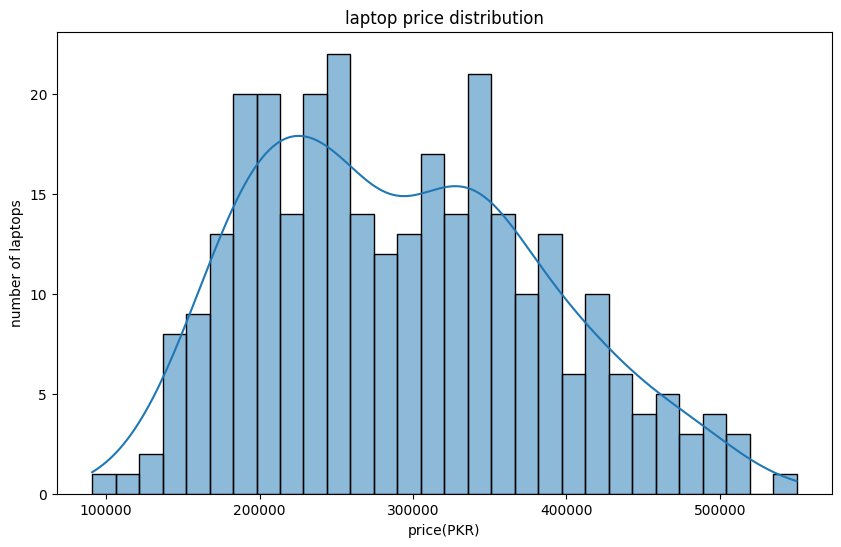

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="price",
    bins=30,
    kde=True
)

plt.title("laptop price distribution")
plt.xlabel("price(PKR)")
plt.ylabel("number of laptops")

plt.show()

In [25]:
brand_prices=(
    df.groupby("brands")["price"]
    .mean()
    .sort_values(ascending=False)
)

brand_prices

brands
HP        316416.666667
Dell      308768.292683
Lenovo    297757.777778
Apple     297304.878049
MSI       280970.212766
Acer      279329.729730
ASUS      267907.547170
Name: price, dtype: float64

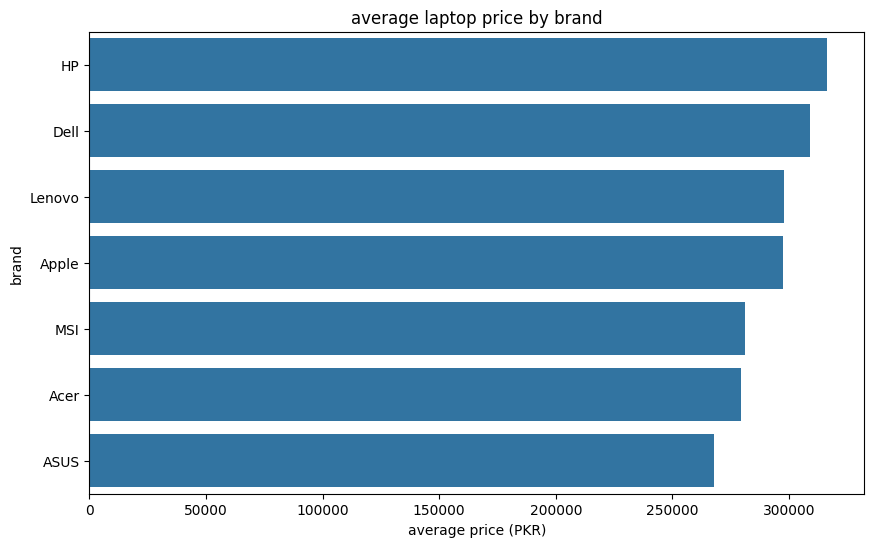

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=brand_prices.values,
    y=brand_prices.index
)

plt.title("average laptop price by brand")
plt.xlabel("average price (PKR)")
plt.ylabel("brand")

plt.show()

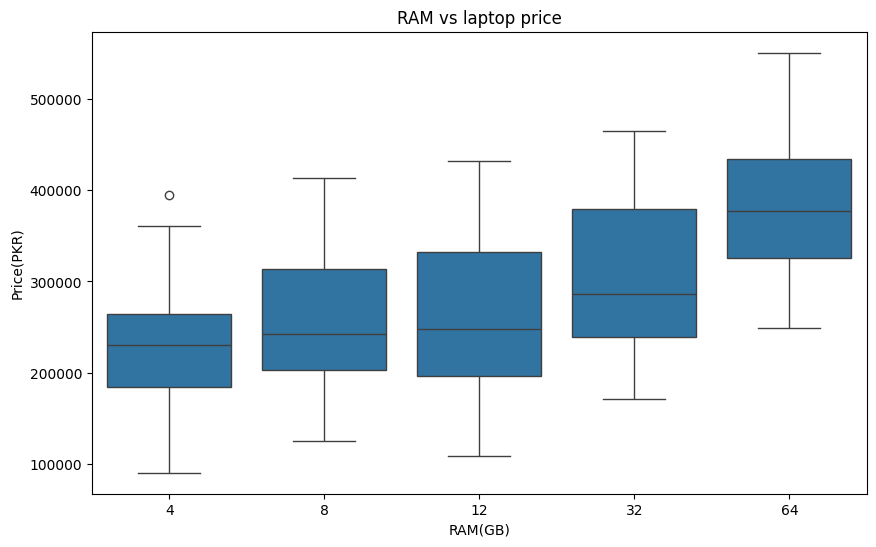

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="ram_gb",
    y="price"
)

plt.title("RAM vs laptop price")
plt.xlabel("RAM(GB)")
plt.ylabel("Price(PKR)")

plt.show()

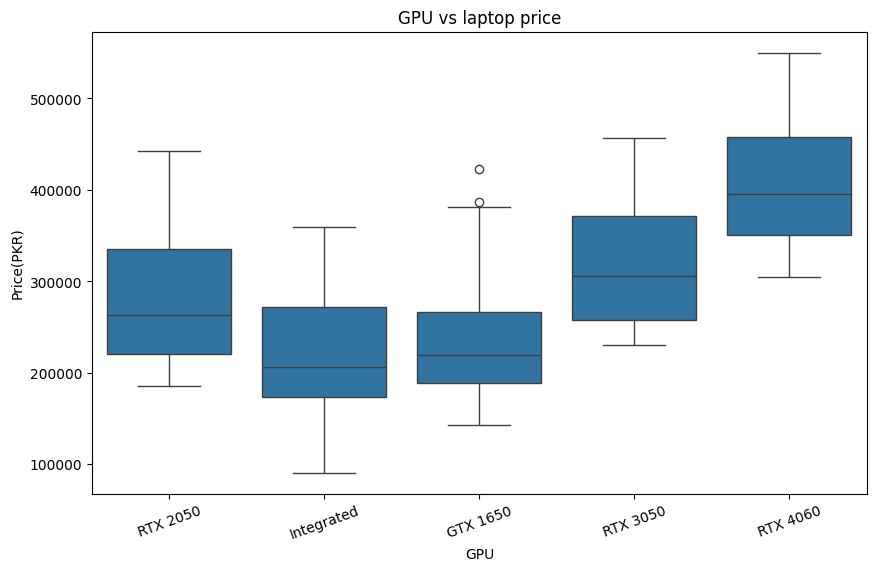

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="gpu",
    y="price"
)

plt.title("GPU vs laptop price")
plt.xlabel("GPU")
plt.ylabel("Price(PKR)")

plt.xticks(rotation=20)

plt.show()

In [29]:
numeric_columns = [
    "ram_gb",
    "Storage_gb",
    "screen_size",
    "battery_hours",
    "weight_kg",
    "processor_score",
    "gpu_scores",
    "price"
]

correlation = df[
    numeric_columns
].corr()

In [30]:
correlation

,ram_gb,Storage_gb,screen_size,battery_hours,weight_kg,processor_score,gpu_scores,price
ram_gb,1.000000,0.000832,-0.127784,-0.013557,0.028843,0.007013,-0.029511,0.600641
Storage_gb,0.000832,1.000000,0.055026,0.034741,0.045200,-0.029206,-0.044194,0.259283
screen_size,-0.127784,0.055026,1.000000,-0.022586,-0.013229,0.045610,0.010195,-0.008893
battery_hours,-0.013557,0.034741,-0.022586,1.000000,-0.051053,0.026716,-0.016753,-0.019413
weight_kg,0.028843,0.045200,-0.013229,-0.051053,1.000000,-0.024474,-0.069682,-0.009114
processor_score,0.007013,-0.029206,0.045610,0.026716,-0.024474,1.000000,0.070242,0.102791
gpu_scores,-0.029511,-0.044194,0.010195,-0.016753,-0.069682,0.070242,1.000000,0.708048
price,0.600641,0.259283,-0.008893,-0.019413,-0.009114,0.102791,0.708048,1.000000


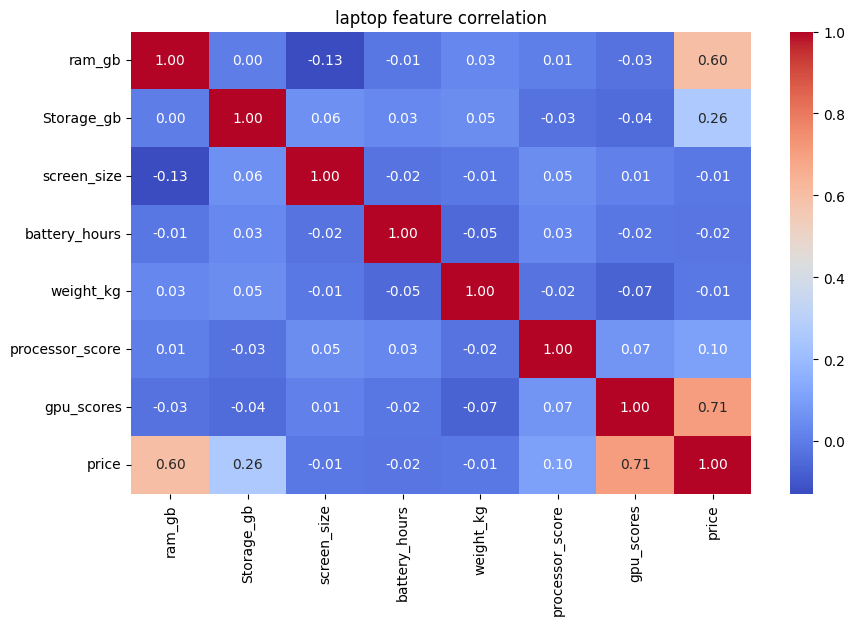

In [31]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("laptop feature correlation")
plt.show()

In [32]:
df["price_per_gb_ram"] = (
    df["price"] / df["ram_gb"]
)

In [33]:
df["price_per_gb_storage"] = (
    df["price"] / df["Storage_gb"]
)

In [36]:
df["performance_score"] = (
    df["processor_score"] * 20
    + df["gpu_scores"] * 15
    + df["ram_gb"]
    + df["Storage_gb"] / 100
)

In [37]:
df["value_score"] = (
    df["performance_score"]
    / df["price"]
) * 100000

In [38]:
df.sort_values(
    "value_score",
    ascending=False
)[
    [
        "model",
        "price",
        "performance_score",
        "value_score"
    ]
].head(10)

,model,price,performance_score,value_score
145,MSI M2 32GB,171500.0,114.56,66.798834
19,ASUS M2 12GB,180400.0,109.56,60.731707
86,ASUS M1 4GB,142500.0,81.56,57.235088
3,MSI M2 4GB,230500.0,131.56,57.075922
168,Lenovo M2 4GB,183400.0,104.28,56.859324
157,MSI M2 32GB,206700.0,117.12,56.661829
23,ASUS M2 12GB,195600.0,109.56,56.012270
239,Dell M2 4GB,208800.0,116.56,55.823755
261,ASUS M2 12GB,196800.0,109.56,55.670732
229,Apple Core i7 12GB,166000.0,92.12,55.493976
